In [3]:
import h5py
import numpy as np
import faiss
import pandas as pd

import seaborn
import os
import matplotlib.pyplot as plt

In [ ]:
def embedding_setup(path):
    ids = []
    embeddings = []

    with h5py.File(path, "r") as hf:
        for sequenceID in hf.keys():
            dataset = hf[sequenceID]
            # On crée un array vide de la bonne taille en Float32
            # dataset.shape  donne la dimension du vecteur (ex: 1024)
            vec = np.empty(dataset.shape, dtype='float32')
            
    
            dataset.read_direct(vec)
            
            ids.append(sequenceID)
            embeddings.append(vec)

    embed_array = np.array(embeddings).astype('float32')
    
    return ids, embed_array
# have to use this function twice : once on query once on reference

In [5]:
def index_search_distances(emb_query,emb_ref):
  
    
    faiss.normalize_L2(emb_query)
    faiss.normalize_L2(emb_ref) #need to normalize to do the Inner product (dot product for cosine similarity)

    d = 1024  #tell faiss how many dimension we're working with
    index = faiss.IndexFlatIP(d) #indexflat = no compression (avoid info loss)  / IP = inner or dot product = the cosine similarity
    index.add(emb_ref) #store the information of organism2 to search through

    distances, indices = index.search(emb_query, k=1)#look through organism2 to compare with organism1 prot and look for the closest neighbor only
#distances store the distances, indices = the row number that match the indice of the list of ids !! genius congrats me :)

    return distances,indices

In [6]:
def extractname_frompath(organismpath) :
    filename = os.path.basename(organismpath)
    nomseul = os.path.splitext(filename)[0]
    label= nomseul.split('_')[0]

    return label

In [35]:
path_Org1 = "/home/cassandre/stage/Cassandre/Embeddings/PROTT5_AVERAGEPOOLING/mus_embedding_protT5_uniprot_proteinembeddings.h5"
path_Org2 = "/home/cassandre/stage/Cassandre/Embeddings/PROTT5_AVERAGEPOOLING/homosapiens_embedding_protT5_uniprot_proteinembeddings.h5"

In [ ]:
        
id1,emb1 = embedding_setup(path_Org1)
id2,emb2 = embedding_setup(path_Org2)
    
label1 = extractname_frompath(path_Org1)
label2 = extractname_frompath(path_Org2)

distances1_2, indices1_2= index_search_distances(emb1,emb2)
distances2_1, indices2_1= index_search_distances(emb2, emb1)
    # run the function twice to get all the closest neighbor

all_closest_neighbors = np.concatenate([distances1_2.flatten(),distances2_1.flatten()])


neighbor_names_2_1 = [id1[idx[0]] for idx in indices2_1]
neighbor_names_1_2 = [id2[idx[0]] for idx in indices1_2]


df1 = pd.DataFrame({'proteinID' : id1, 'closest_Neighbor' : neighbor_names_1_2, 'similarité' : distances1_2.flatten(), 'species' : label1  })
df2 = pd.DataFrame({'proteinID' : id2, 'closest_Neighbor' : neighbor_names_2_1, 'similarité' : distances2_1.flatten(), 'species' : label2  })

df_allorganism = pd.concat([df1,df2],ignore_index=True)
df_allorganism = df_allorganism.sort_values(by=["similarité"])

print(df_allorganism.head(500).to_string())

pri


                            proteinID                closest_Neighbor  similarité      species
20908          tr|Q8C7T0|Q8C7T0_MOUSE  tr|A0A1W2PRE2|A0A1W2PRE2_HUMAN    0.477131          mus
19454          tr|F6ZVF2|F6ZVF2_MOUSE  tr|A0A1W2PRE2|A0A1W2PRE2_HUMAN    0.498533          mus
31110           sp|Q58A44|PCOTH_HUMAN          tr|Q5SQK8|Q5SQK8_MOUSE    0.504010  homosapiens
42434  tr|A0AAG2TVH8|A0AAG2TVH8_HUMAN          tr|E9Q6B9|E9Q6B9_MOUSE    0.506409  homosapiens
42439  tr|A0AAG2TWI1|A0AAG2TWI1_HUMAN          tr|E9Q6B9|E9Q6B9_MOUSE    0.507496  homosapiens
20806          tr|Q8BGG2|Q8BGG2_MOUSE           sp|Q96M78|FEAS2_HUMAN    0.507722          mus
19259          tr|E9Q5K2|E9Q5K2_MOUSE           sp|Q9HBX3|SNIT1_HUMAN    0.510926          mus
23632            sp|O15428|PINL_HUMAN          tr|Q3UKW5|Q3UKW5_MOUSE    0.511641  homosapiens
34370           sp|Q8N2A0|CX062_HUMAN          tr|Q9CXH3|Q9CXH3_MOUSE    0.512019  homosapiens
30276           sp|Q15486|GUSP1_HUMAN          tr|

In [ ]:

deviationstd_similarity = df_allorganism['similarité'].std()

mean_similarity= df_allorganism['similarité'].mean()
outliers_cutoff= mean_similarity-(3*deviationstd_similarity)

print(f"Seuil IQR : {cutoff_iqr:.4f}")
print(f"Nombre d'outliers avec IQR : {len(df_allorganism[df_allorganism['similarité'] < cutoff_iqr])}")


print(outliers_cutoff)
print(f"Nombre d'outliers avec IQR : {len(df_allorganism[df_allorganism['similarité'] < outliers_cutoff])}")



Seuil IQR : 0.9263
Nombre d'outliers avec IQR : 5133
0.8089947812259197
Nombre d'outliers avec IQR : 1254


Text(0, 0.5, 'Densité')

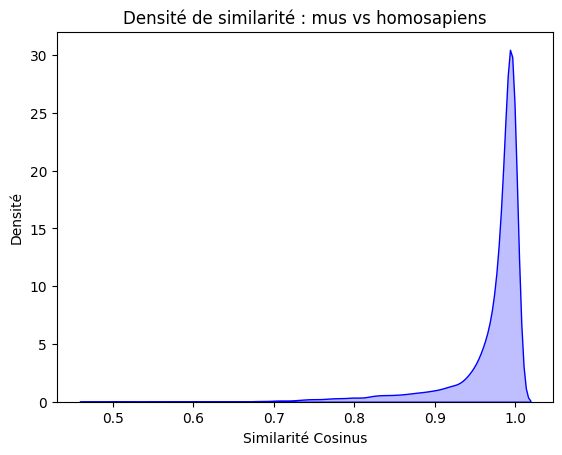

In [37]:
seaborn.kdeplot(data = df_allorganism,x="similarité",fill=True, color="blue")
plt.title(f"Densité de similarité : {label1} vs {label2}")
plt.xlabel("Similarité Cosinus") #1 = identité, 0 = très très différent
plt.ylabel("Densité")

In [12]:
#code to add protein under the cutoff distance to a list 
# can then be used in the other umap print script so i can change the color of the outliers


is_outlier = df_allorganism['similarité'] < cutoff_iqr

outlier_list = df_allorganism.loc[is_outlier, 'proteinID'].tolist()

print(f"Nombre d'IDs dans la liste : {len(outlier_list)}")

outlier_list

Nombre d'IDs dans la liste : 5133


['tr|Q8C7T0|Q8C7T0_MOUSE',
 'tr|F6ZVF2|F6ZVF2_MOUSE',
 'sp|Q58A44|PCOTH_HUMAN',
 'tr|A0AAG2TVH8|A0AAG2TVH8_HUMAN',
 'tr|A0AAG2TWI1|A0AAG2TWI1_HUMAN',
 'tr|Q8BGG2|Q8BGG2_MOUSE',
 'tr|E9Q5K2|E9Q5K2_MOUSE',
 'sp|O15428|PINL_HUMAN',
 'sp|Q8N2A0|CX062_HUMAN',
 'sp|Q15486|GUSP1_HUMAN',
 'sp|A0A096LPI5|GVQW2_HUMAN',
 'sp|A6NIU2|CU037_HUMAN',
 'tr|A0AAG2TTM8|A0AAG2TTM8_HUMAN',
 'sp|A8MQ11|PM2P5_HUMAN',
 'sp|Q6ZRU5|YQ032_HUMAN',
 'sp|Q6UXP3|TM14E_HUMAN',
 'tr|A0A1W2P738|A0A1W2P738_MOUSE',
 'sp|A6NDN8|UBIML_HUMAN',
 'sp|Q6ZN92|DUTL_HUMAN',
 'sp|Q86U02|CN165_HUMAN',
 'sp|Q8N9W7|YO010_HUMAN',
 'sp|A6NDX4|YO011_HUMAN',
 'sp|Q6XLA1|CSC2A_HUMAN',
 'sp|P63121|VP113_HUMAN',
 'sp|P63124|VPK04_HUMAN',
 'sp|Q5NE16|CATL3_HUMAN',
 'sp|Q8N976|YG039_HUMAN',
 'sp|A0A1W2PPG7|GBG14_HUMAN',
 'tr|A0A991EQU4|A0A991EQU4_MOUSE',
 'tr|A0A0A0MT82|A0A0A0MT82_HUMAN',
 'sp|O00198|HRK_HUMAN',
 'sp|Q9BZA0|TTY10_HUMAN',
 'sp|Q6NVV0|MKRN5_HUMAN',
 'tr|A0A087WPV9|A0A087WPV9_MOUSE',
 'sp|Q8TBR4|ST3L4_HUMAN',
 'sp|P59091|CU093_H

In [13]:
output_folder = "/home/cassandre/stage/Cassandre/panthr_text/"


outlier_org1 = [p for p in outlier_list if p in id1]
outlier_org2 = [p for p in outlier_list if p in id2]

def clean_uniprot(id_list):
    return [p.split('|')[1] if '|' in p else p for p in id_list]

# Nettoyage listes
id1_clean = clean_uniprot(id1)
id2_clean = clean_uniprot(id2)
outliers_org1_clean = clean_uniprot(outlier_org1)
outliers_org2_clean = clean_uniprot(outlier_org2)


with open(output_folder + "background_" + label1 + ".txt", "w") as f:
    f.write("\n".join(id1_clean))

with open(output_folder + "outliers_" + label1 + ".txt", "w") as f:
    f.write("\n".join(outliers_org1_clean))


with open(output_folder + "background_" + label2 + ".txt", "w") as f:
    f.write("\n".join(id2_clean))


with open(output_folder + "outliers_" + label2 + ".txt", "w") as f:
    f.write("\n".join(outliers_org2_clean))




In [2]:
#make code to figure out mean sequence length of all the proteomes and the mean length of the sequence that are in my outliers list

def clean_uniprot(protein_id):
    if '|' in protein_id:
        return protein_id.split('|')[1]
    return protein_id

def get_lengths_from_fasta(fastafile):
    lengths = {} 
    current_id = None    
    current_seq = ""      

    with open(fastafile, 'r') as f:
        for line in f:
            line = line.strip() 
            if not line: continue 
            
            if line.startswith('>'):
                if current_id is not None:
                    lengths[current_id] = len(current_seq)
                
               
                full_id = line.split()[0][1:] 
    
                current_id = clean_uniprot(full_id)
                
                current_seq = "" 
            else:
                current_seq += line
        
    
        if current_id is not None:
            lengths[current_id] = len(current_seq)
            
    return lengths




In [31]:
length_chicken=get_lengths_from_fasta("/home/cassandre/stage/Cassandre/Proteome/UniProt/UP000000589_10090.fa")
length_human = get_lengths_from_fasta("/home/cassandre/stage/Cassandre/Proteome/UniProt/UP000005640_9606.fa")




In [18]:
print(outlier_list)
len(outlier_list)

['tr|Q8C7T0|Q8C7T0_MOUSE', 'tr|F6ZVF2|F6ZVF2_MOUSE', 'sp|Q58A44|PCOTH_HUMAN', 'tr|A0AAG2TVH8|A0AAG2TVH8_HUMAN', 'tr|A0AAG2TWI1|A0AAG2TWI1_HUMAN', 'tr|Q8BGG2|Q8BGG2_MOUSE', 'tr|E9Q5K2|E9Q5K2_MOUSE', 'sp|O15428|PINL_HUMAN', 'sp|Q8N2A0|CX062_HUMAN', 'sp|Q15486|GUSP1_HUMAN', 'sp|A0A096LPI5|GVQW2_HUMAN', 'sp|A6NIU2|CU037_HUMAN', 'tr|A0AAG2TTM8|A0AAG2TTM8_HUMAN', 'sp|A8MQ11|PM2P5_HUMAN', 'sp|Q6ZRU5|YQ032_HUMAN', 'sp|Q6UXP3|TM14E_HUMAN', 'tr|A0A1W2P738|A0A1W2P738_MOUSE', 'sp|A6NDN8|UBIML_HUMAN', 'sp|Q6ZN92|DUTL_HUMAN', 'sp|Q86U02|CN165_HUMAN', 'sp|Q8N9W7|YO010_HUMAN', 'sp|A6NDX4|YO011_HUMAN', 'sp|Q6XLA1|CSC2A_HUMAN', 'sp|P63121|VP113_HUMAN', 'sp|P63124|VPK04_HUMAN', 'sp|Q5NE16|CATL3_HUMAN', 'sp|Q8N976|YG039_HUMAN', 'sp|A0A1W2PPG7|GBG14_HUMAN', 'tr|A0A991EQU4|A0A991EQU4_MOUSE', 'tr|A0A0A0MT82|A0A0A0MT82_HUMAN', 'sp|O00198|HRK_HUMAN', 'sp|Q9BZA0|TTY10_HUMAN', 'sp|Q6NVV0|MKRN5_HUMAN', 'tr|A0A087WPV9|A0A087WPV9_MOUSE', 'sp|Q8TBR4|ST3L4_HUMAN', 'sp|P59091|CU093_HUMAN', 'sp|Q6PK57|DMP34_HUMAN', 'sp

5133

In [32]:
outliers_clean = [p.split('|')[1] if '|' in p else p for p in outlier_list]
all_lengths_dict = {**length_chicken, **length_human}
all_lengths_values = list(all_lengths_dict.values())
outliers_lengths_values = [all_lengths_dict[p] for p in outliers_clean if p in all_lengths_dict]

mean_bg = np.mean(all_lengths_values)
mean_out = np.mean(outliers_lengths_values)

print(f"Moyenne full proteome : {mean_bg:.1f} AA")
print(f"Moyenne Outliers : {mean_out:.1f} AA")




Moyenne full proteome : 547.0 AA
Moyenne Outliers : 357.7 AA


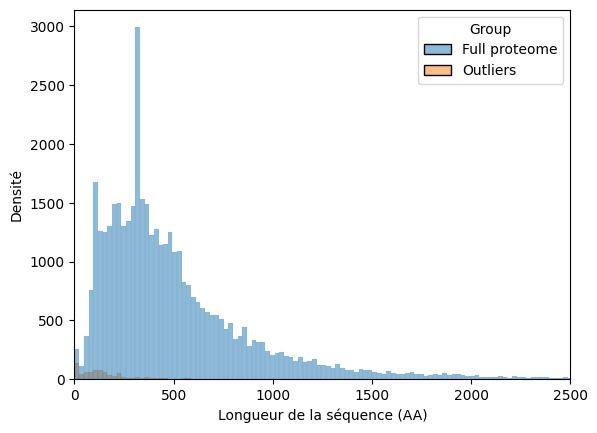

546.9950130554445
428.6350606394708


In [28]:
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd

df_bg = pd.DataFrame({'Length': all_lengths_values, 'Group': 'Full proteome'})
df_out = pd.DataFrame({'Length': outliers_lengths_values, 'Group': 'Outliers'})
df_plot = pd.concat([df_bg, df_out])


#sns.kdeplot(data=df_plot, x="Length", hue= "Group", fill=True, common_norm=False)
sns.histplot(data=df_plot, x="Length", hue= "Group")

plt.xlabel("Longueur de la séquence (AA)")
plt.ylabel("Densité")

plt.xlim(0, 2500) 

plt.show()

print(df_bg['Length'].mean())
print(df_out['Length'].mean())

Nombre d'outliers récupérés : 574


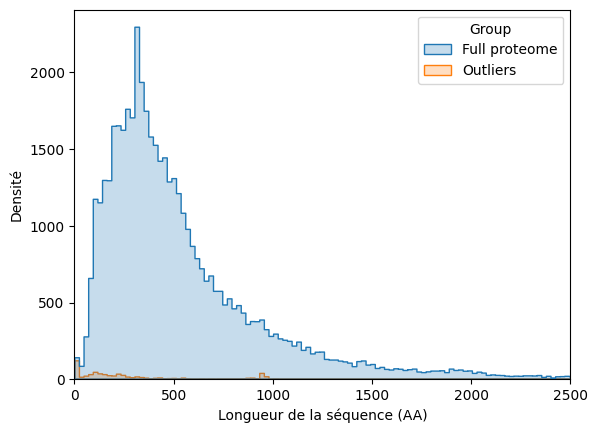

In [3]:
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd

proteome1 = '/home/cassandre/stage/Cassandre/Proteome/UniProt/UP000005640_9606.fa' # human
proteome2 = '/home/cassandre/stage/Cassandre/Proteome/UniProt/UP000000437_7955.fa' # mouse

outliers_files = [
    '/home/cassandre/stage/Cassandre/results/panthr_text/human_fish/human_fishoutliers_homosapiens.txt', 
    '/home/cassandre/stage/Cassandre/results/panthr_text/human_fish/human_fishoutliers_zebrafish.txt'
]

length_prot1 = get_lengths_from_fasta(proteome1)
length_prot2 = get_lengths_from_fasta(proteome2)
all_lengths_dict = {**length_prot1, **length_prot2} 


outliers_length_dict = {}
for file_path in outliers_files:
    with open(file_path, 'r') as f:
        for line in f:
            protein_id = line.strip()
            if not protein_id: continue 
            
            if protein_id in all_lengths_dict:
                outliers_length_dict[protein_id] = all_lengths_dict[protein_id]
            else:
                print(f"Attention : {protein_id} non trouvé dans les FASTAs")

print(f"Nombre d'outliers récupérés : {len(outliers_length_dict)}")

all_lengths_values = list(all_lengths_dict.values())
outliers_lengths_values = list(outliers_length_dict.values())

df_bg = pd.DataFrame({'Length': all_lengths_values, 'Group': 'Full proteome'})
df_out = pd.DataFrame({'Length': outliers_lengths_values, 'Group': 'Outliers'})
df_plot = pd.concat([df_bg, df_out])


#sns.kdeplot(data=df_plot, x="Length", hue= "Group", fill=True, common_norm=False)
sns.histplot(data=df_plot, x="Length", hue= "Group",element="step")

plt.xlabel("Longueur de la séquence (AA)")
plt.ylabel("Densité")

plt.xlim(0, 2500) 

plt.show()

In [4]:
print(sum(all_lengths_values) / len(all_lengths_values))
print(sum(outliers_lengths_values) / len(outliers_lengths_values))

580.2913013309784
268.10104529616723
